In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import confusion_matrix
from wordcloud import WordCloud
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [4]:
import spacy
nlp=spacy.load("en_core_web_sm")

In [5]:
df=pd.read_csv("c:/Users/Admin/Downloads/chatgpt_style_reviews_dataset.xlsx - Sheet1.csv")

In [6]:
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,2024-09-06,Claim who accept.,Every quite sense including six lot have never...,4,morrowthomas,30,22,Flipkart,ar,Nepal,3.8.4,No
1,3/7/2025,Growth pretty wish.,Ask develop bag also his worker pass. Expert w...,4,sheakimberly,120,22,Flipkart,ar,Guinea,5.2.6,Yes
2,########,What then spend offer reason whom none.,If customer address region try near risk next ...,5,katherineali,130,21,Flipkart,es,Kuwait,3.6.5,No
3,########,Say dog drug enter director strong student.,To television loss election him small detail r...,1,eric11,72,26,Amazon,pt,Uruguay,5.7.2,No
4,########,Purpose here beyond.,Pass share must amount lot per manage world to...,5,chloe42,123,27,Amazon,zh,Mayotte,5.8.6,No


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               250 non-null    object
 1   title              250 non-null    object
 2   review             250 non-null    object
 3   rating             250 non-null    int64 
 4   username           250 non-null    object
 5   helpful_votes      250 non-null    int64 
 6   review_length      250 non-null    int64 
 7   platform           250 non-null    object
 8   language           250 non-null    object
 9   location           250 non-null    object
 10  version            250 non-null    object
 11  verified_purchase  250 non-null    object
dtypes: int64(3), object(9)
memory usage: 23.6+ KB


In [8]:
df.shape

(250, 12)

In [9]:
#create separate column for sentiment target variable

def sentiment_col(rating):
  if rating<=2:
    return "Negative"
  elif rating==3:
    return "Neutral"
  else:
    return "Positive"

df['sentiment'] = df['rating'].apply(sentiment_col) #convert rating into sentiment

df['sentiment'].value_counts()

sentiment
Negative    97
Positive    96
Neutral     57
Name: count, dtype: int64

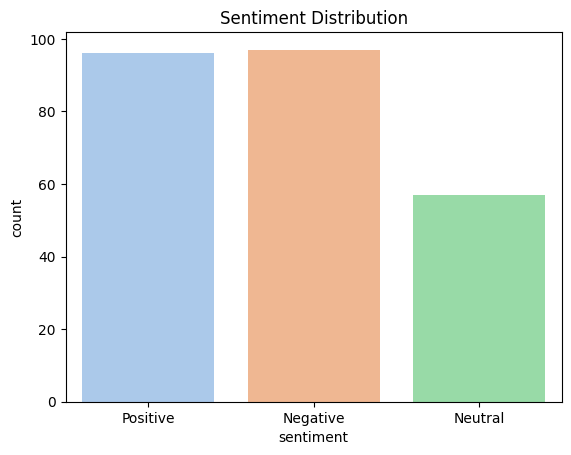

In [274]:
sns.countplot(data=df, x='sentiment', palette='pastel')
plt.title('Sentiment Distribution')
plt.show()

In [10]:
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)

    doc = nlp(text)

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_punct 
    ]

    return " ".join(tokens)

In [11]:
df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review"]].head()

,review,clean_review
0,Every quite sense including six lot have never...,every quite sense include six lot have never e...
1,Ask develop bag also his worker pass. Expert w...,ask develop bag also his worker pass expert wh...
2,If customer address region try near risk next ...,if customer address region try near risk next ...
3,To television loss election him small detail r...,to television loss election he small detail re...
4,Pass share must amount lot per manage world to...,pass share must amount lot per manage world to...


In [12]:
df['sentiment'] = df['sentiment'].map({
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
})

In [13]:
df['sentiment'].value_counts()

sentiment
0    97
2    96
1    57
Name: count, dtype: int64

In [14]:
cleaned_df = df[[
        "date",
        "review",
        "clean_review",
        "rating",
        "sentiment",
        "platform",
        "location",
        "version",
        "verified_purchase",
        "helpful_votes"]
]
cleaned_df.to_csv("cleaned_reviews.csv", index=False)

In [15]:
x = df["clean_review"]
y = df["sentiment"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 200
Testing samples: 50


In [16]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200,random_state=42),
}

In [19]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ("classifier", model)
    ])

In [20]:
results = []

for name, pipeline in pipelines.items():
    # Train
    pipeline.fit(x_train, y_train)

    # Predictions
    y_pred = pipeline.predict(x_test)

    # Some models may not support predict_proba
    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(x_test)
        roc_auc = roc_auc_score(
            y_test, y_prob, multi_class="ovr", average="macro"
        )
    else:
        roc_auc = None

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    macro_f1 = report["macro avg"]["f1-score"]

    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "ROC_AUC": roc_auc,
        "F1 Score": macro_f1,
        "Pipeline": pipeline,
        "Report": report
    })

In [21]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print(results_df)

                 Model  Accuracy   ROC_AUC  F1 Score  \
0          Naive Bayes      0.40  0.482763  0.304446   
1             AdaBoost      0.36  0.506154  0.278321   
2  Logistic Regression      0.36  0.494388  0.272807   
3        Random Forest      0.28  0.484991  0.207737   

                                            Pipeline  \
0  (TfidfVectorizer(max_features=10000, ngram_ran...   
1  (TfidfVectorizer(max_features=10000, ngram_ran...   
2  (TfidfVectorizer(max_features=10000, ngram_ran...   
3  (TfidfVectorizer(max_features=10000, ngram_ran...   

                                              Report  
0  {'0': {'precision': 0.35714285714285715, 'reca...  
1  {'0': {'precision': 0.42857142857142855, 'reca...  
2  {'0': {'precision': 0.3333333333333333, 'recal...  
3  {'0': {'precision': 0.28125, 'recall': 0.47368...  


In [22]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = results_df.iloc[0]["Pipeline"]

print("Best Model:", best_model_name)

Best Model: Naive Bayes


In [23]:
from joblib import dump
dump(best_pipeline, "best_sentiment_model.joblib")

['best_sentiment_model.joblib']

In [24]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

results_df

,Model,Accuracy,ROC_AUC,F1 Score,Pipeline,Report
0,Naive Bayes,0.40,0.482763,0.304446,"(TfidfVectorizer(max_features=10000, ngram_ran...","{'0': {'precision': 0.35714285714285715, 'reca..."
1,AdaBoost,0.36,0.506154,0.278321,"(TfidfVectorizer(max_features=10000, ngram_ran...","{'0': {'precision': 0.42857142857142855, 'reca..."
2,Logistic Regression,0.36,0.494388,0.272807,"(TfidfVectorizer(max_features=10000, ngram_ran...","{'0': {'precision': 0.3333333333333333, 'recal..."
3,Random Forest,0.28,0.484991,0.207737,"(TfidfVectorizer(max_features=10000, ngram_ran...","{'0': {'precision': 0.28125, 'recall': 0.47368..."


In [25]:
best_model_name = results_df.iloc[0]["Model"]
best_model_name

'Naive Bayes'

In [26]:
best_pipeline = pipelines[best_model_name]
y_best_pred = best_pipeline.predict(x_test)

cm_best = confusion_matrix(y_test, y_best_pred)
cm_best

array([[10,  0,  9],
       [ 9,  0,  3],
       [ 9,  0, 10]])

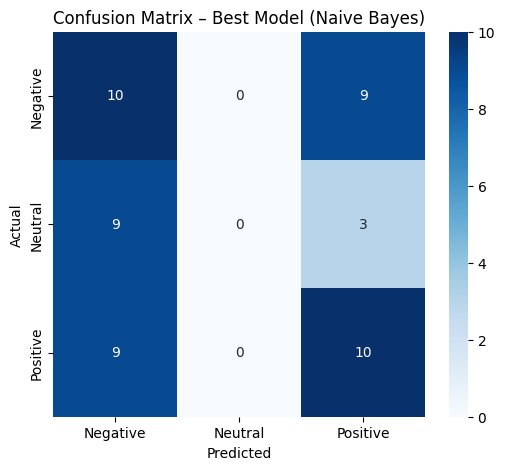

In [27]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best,annot=True,fmt="d",cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"])

plt.title(f"Confusion Matrix – Best Model ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

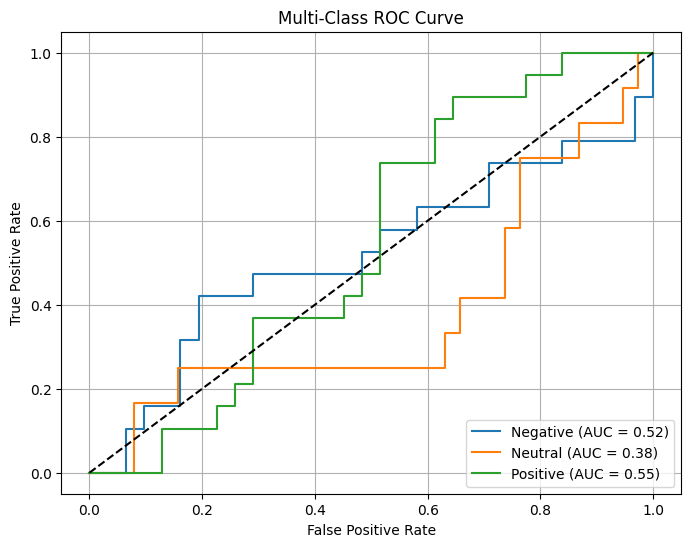

In [28]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

y_prob = best_pipeline.predict_proba(x_test)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# plotting ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr[0], tpr[0], label=f"Negative (AUC = {roc_auc[0]:.2f})")
plt.plot(fpr[1], tpr[1], label=f"Neutral (AUC = {roc_auc[1]:.2f})")
plt.plot(fpr[2], tpr[2], label=f"Positive (AUC = {roc_auc[2]:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [29]:
from joblib import dump
dump(best_pipeline, "best_sentiment_model.joblib")

['best_sentiment_model.joblib']

In [30]:
#LSTM
tokenizer = Tokenizer()
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

In [31]:
tokenizer.word_index

{'across': 1,
 'fact': 2,
 'short': 3,
 'picture': 4,
 'other': 5,
 'include': 6,
 'good': 7,
 'beat': 8,
 'wife': 9,
 'south': 10,
 'i': 11,
 'case': 12,
 'series': 13,
 'special': 14,
 'produce': 15,
 'total': 16,
 'mission': 17,
 'decide': 18,
 'major': 19,
 'huge': 20,
 'machine': 21,
 'when': 22,
 'truth': 23,
 'they': 24,
 'event': 25,
 'everyone': 26,
 'easy': 27,
 'artist': 28,
 'guess': 29,
 'goal': 30,
 'think': 31,
 'red': 32,
 'where': 33,
 'chance': 34,
 'loss': 35,
 'eat': 36,
 'leave': 37,
 'lot': 38,
 'run': 39,
 'manager': 40,
 'his': 41,
 'mention': 42,
 'front': 43,
 'third': 44,
 'together': 45,
 'question': 46,
 'develop': 47,
 'outside': 48,
 'mrs': 49,
 'woman': 50,
 'article': 51,
 'consider': 52,
 'himself': 53,
 'practice': 54,
 'interest': 55,
 'computer': 56,
 'be': 57,
 'summer': 58,
 'four': 59,
 'population': 60,
 'wide': 61,
 'well': 62,
 'grow': 63,
 'personal': 64,
 'process': 65,
 'mind': 66,
 'western': 67,
 'concern': 68,
 'feel': 69,
 'few': 70,
 '

In [32]:
total_words = len(tokenizer.word_index)

total_words

958

In [33]:
max_len = 100

x_train_pad = pad_sequences(x_train_seq,maxlen=max_len,padding="post",truncating="post")

x_test_pad = pad_sequences(x_test_seq,maxlen=max_len,padding="post",truncating="post")

In [34]:
# Convert labels to categorical (using one-hot)
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

In [35]:
model = Sequential([
    Embedding(total_words + 1, 128, input_length=max_len),
    LSTM(150,recurrent_dropout=0.1),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [36]:
lstm_model = model.fit(x_train_pad,y_train_cat,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.3938 - loss: 1.0853 - val_accuracy: 0.2000 - val_loss: 1.1170
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.4375 - loss: 1.0690 - val_accuracy: 0.2000 - val_loss: 1.1631
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.4375 - loss: 1.0645 - val_accuracy: 0.2000 - val_loss: 1.1192
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.4375 - loss: 1.0615 - val_accuracy: 0.2000 - val_loss: 1.1360
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4375 - loss: 1.0614 - val_accuracy: 0.2000 - val_loss: 1.1584
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.4375 - loss: 1.0622 - val_accuracy: 0.2000 - val_loss: 1.1534
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.4375 - loss: 1.0601 - val_accuracy: 0.2000 - val_loss: 1.1334
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.4375 - loss: 1.0612 - val_accuracy: 0.2000 - val_loss:

In [37]:
loss, accuracy = model.evaluate(x_test_pad, y_test_cat)
print("LSTM Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3800 - loss: 1.0827
LSTM Test Accuracy: 0.3799999952316284


In [38]:
#BERT MODEL

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np


In [39]:
# Convert to string
x_train = x_train.astype(str)
x_test = x_test.astype(str)

# Create HuggingFace dataset
train_dataset = Dataset.from_dict({
    "text": list(x_train),
    "label": list(y_train)
})

test_dataset = Dataset.from_dict({
    "text": list(x_test),
    "label": list(y_test)
})

In [40]:
# Tokenization
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 50/50 [00:00<00:00, 3600.38 examples/s]


In [41]:
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2760.48it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

In [42]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

In [43]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5
)

In [44]:
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [45]:
trainer.train()

predictions = trainer.predict(test_dataset)

print("BERT Results:", predictions.metrics)

Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.70it/s]


BERT Results: {'test_loss': 1.0543721914291382, 'test_accuracy': 0.46, 'test_f1': 0.32873563218390806, 'test_runtime': 5.9181, 'test_samples_per_second': 8.449, 'test_steps_per_second': 1.183}


In [46]:
y_pred = predictions.predictions.argmax(axis=1)
y_true = y_test.values

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.44      0.89      0.59        19
           1       0.00      0.00      0.00        12
           2       0.55      0.32      0.40        19

    accuracy                           0.46        50
   macro avg       0.33      0.40      0.33        50
weighted avg       0.37      0.46      0.37        50



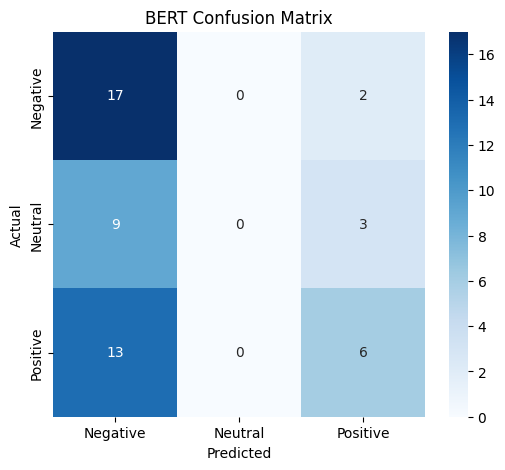

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Confusion Matrix")
plt.show()

In [50]:
bert_acc = predictions.metrics["test_accuracy"]
bert_f1 = predictions.metrics["test_f1"]

final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Random Forest", "LSTM", "BERT"],
    "Accuracy": [0.48, 0.44, 0.38, 0.38, bert_acc],
    "F1 Score": [0.40, 0.38, 0.28, 0.37, bert_f1]
})

print(final_results)

                 Model  Accuracy  F1 Score
0  Logistic Regression      0.48  0.400000
1          Naive Bayes      0.44  0.380000
2        Random Forest      0.38  0.280000
3                 LSTM      0.38  0.370000
4                 BERT      0.46  0.328736


In [51]:
trainer.save_model("bert_sentiment_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.69it/s]


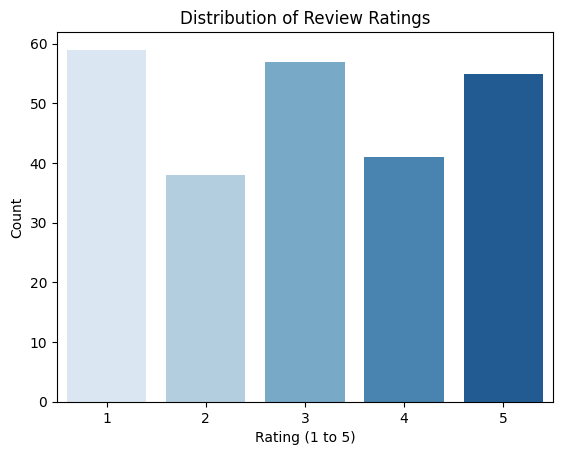

In [52]:
#EDA
# 1.Distribution of Ratings

sns.countplot(x="rating", data=df, palette="Blues")
plt.title("Distribution of Review Ratings")
plt.xlabel("Rating (1 to 5)")
plt.ylabel("Count")
plt.show()

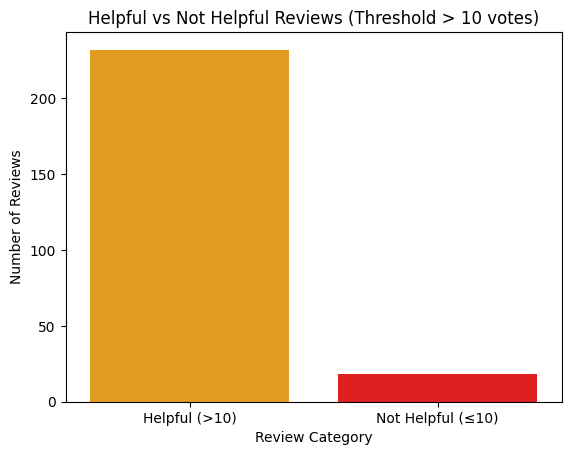

In [243]:
# 2. How many reviews were marked as helpful (above a certain threshold)?

threshold = 10

df["helpful_category"] = df["helpful_votes"].apply(lambda x: "Helpful (>10)" if x > threshold else "Not Helpful (≤10)")

sns.countplot(x="helpful_category",data=df,palette=["orange", "red"])

plt.title("Helpful vs Not Helpful Reviews (Threshold > 10 votes)")
plt.xlabel("Review Category")
plt.ylabel("Number of Reviews")
plt.show()

In [244]:
df["helpful_category"].value_counts()

helpful_category
Helpful (>10)        232
Not Helpful (≤10)     18
Name: count, dtype: int64

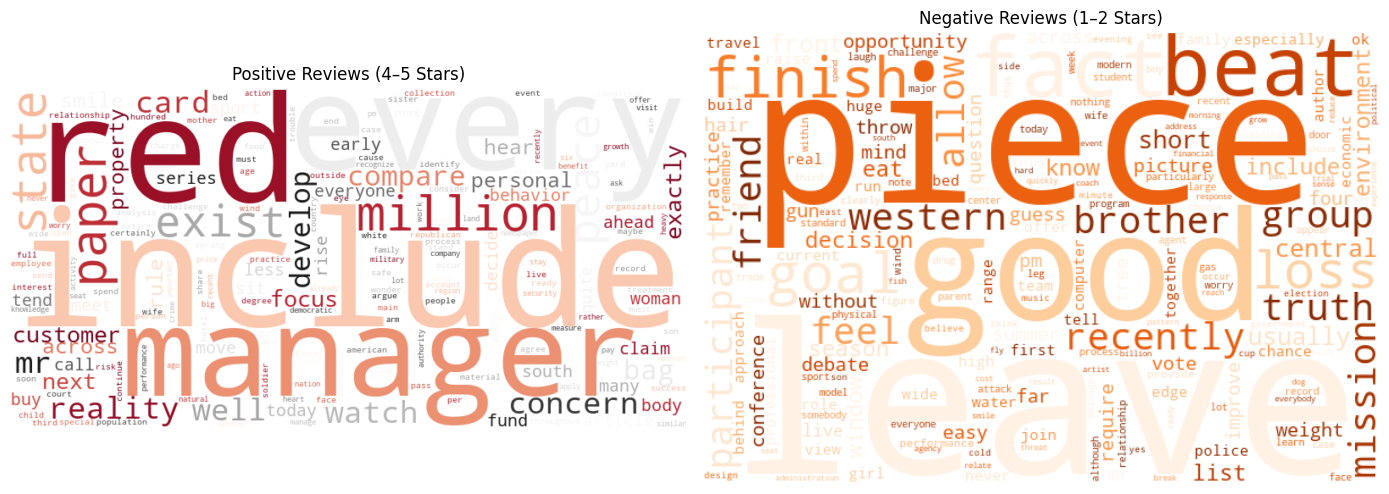

In [245]:
# 3. What are the most common keywords in positive vs. negative reviews?

positive_reviews = df[df["rating"] >= 4]["clean_review"]
negative_reviews = df[df["rating"] <= 2]["clean_review"]

positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)

positive_wc = WordCloud(width=800,height=400,background_color="white",colormap="RdGy").generate(positive_text)
negative_wc = WordCloud(width=600,height=400,background_color="white",colormap="Oranges").generate(negative_text)

plt.figure(figsize=(14, 6))

# Positive reviews word cloud
plt.subplot(1, 2, 1)
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews (4–5 Stars)")

# Negative reviews word cloud
plt.subplot(1, 2, 2)
plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews (1–2 Stars)")

plt.tight_layout()
plt.show()

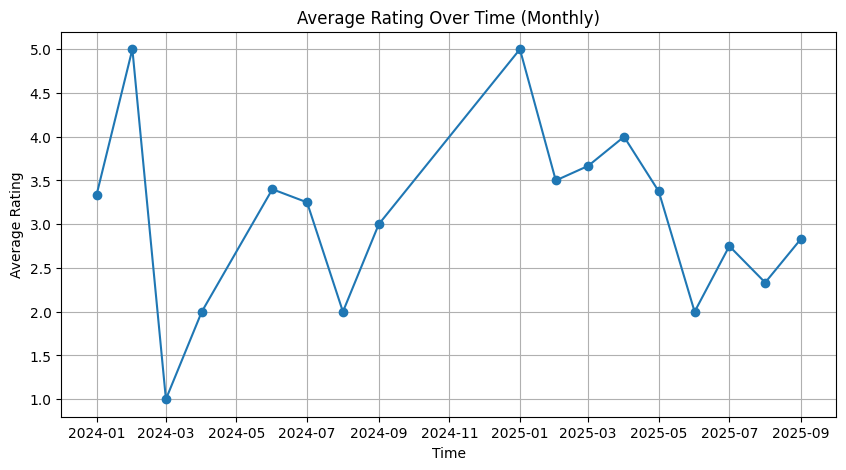

In [246]:
# 4. How has the average rating changed over time?

df["date"] = pd.to_datetime(df["date"], format="mixed", dayfirst=True, errors="coerce")

df["year_month"] = df["date"].dt.to_period("M")

monthly_avg = df.groupby("year_month")["rating"].mean()

monthly_avg.index = monthly_avg.index.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")

plt.title("Average Rating Over Time (Monthly)")
plt.xlabel("Time")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()

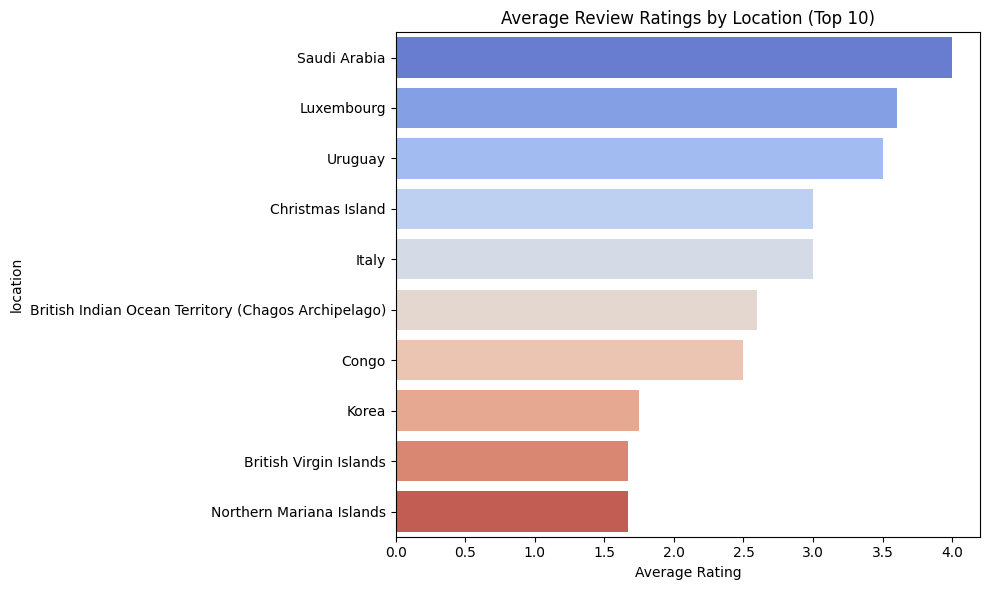

In [247]:
# 5. How do ratings vary by user location?

top_countries = df['location'].value_counts().nlargest(10).index
filtered_df = df[df['location'].isin(top_countries)]

avg_rating_by_location = filtered_df.groupby('location')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rating_by_location.values, y=avg_rating_by_location.index, palette="coolwarm")
plt.xlabel('Average Rating')
plt.title('Average Review Ratings by Location (Top 10)')
plt.tight_layout()
plt.show()

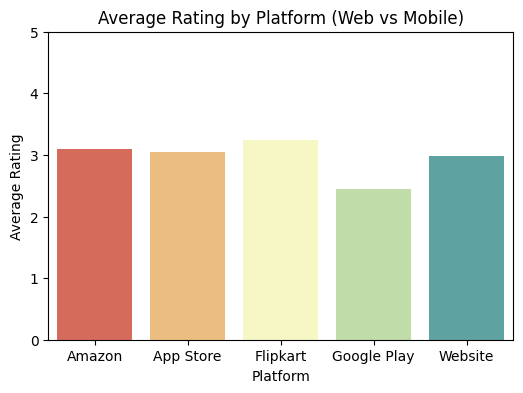

In [248]:
# 6. Which platform (Web vs Mobile) gets better reviews?

platform_avg = df.groupby("platform")["rating"].mean().reset_index()

plt.figure(figsize=(6, 4))

sns.barplot(data=platform_avg,x="platform",y="rating",palette="Spectral")

plt.title("Average Rating by Platform (Web vs Mobile)")
plt.xlabel("Platform")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.show()

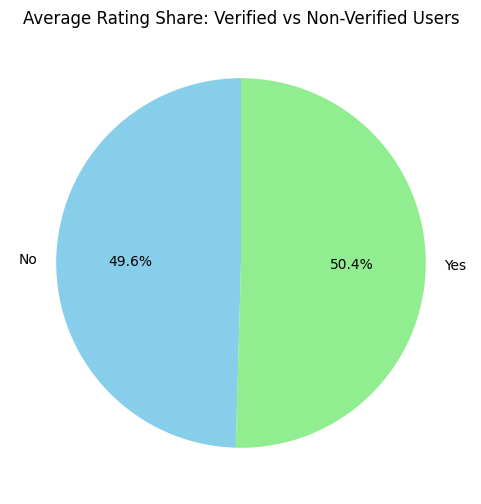

In [249]:
#  7. Are verified users more satisfied than non-verified ones?

verified_avg = (df.groupby("verified_purchase")["rating"].mean().reset_index())

plt.figure(figsize=(6, 6))
plt.pie(verified_avg["rating"],labels=verified_avg["verified_purchase"],autopct="%1.1f%%",startangle=90,colors=["skyblue", "lightgreen"])

plt.title("Average Rating Share: Verified vs Non-Verified Users")
plt.show()

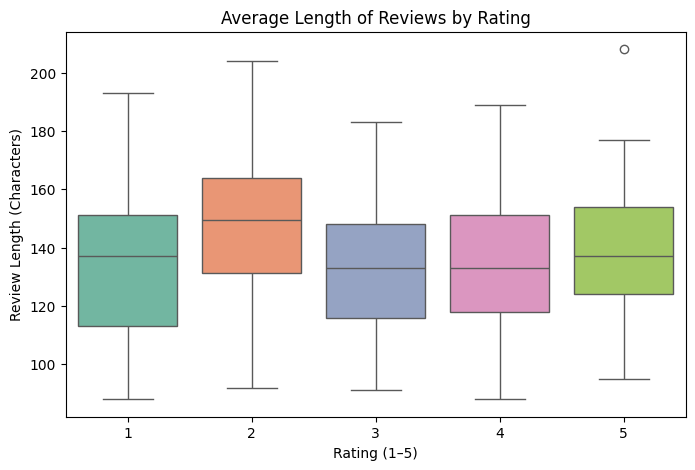

In [250]:
# 8. What’s the average length of reviews per rating category?

df["review_length"] = df["review"].astype(str).apply(len)

plt.figure(figsize=(8, 5))

sns.boxplot(data=df,x="rating",y="review_length",palette="Set2")

plt.title("Average Length of Reviews by Rating")
plt.xlabel("Rating (1–5)")
plt.ylabel("Review Length (Characters)")
plt.show()

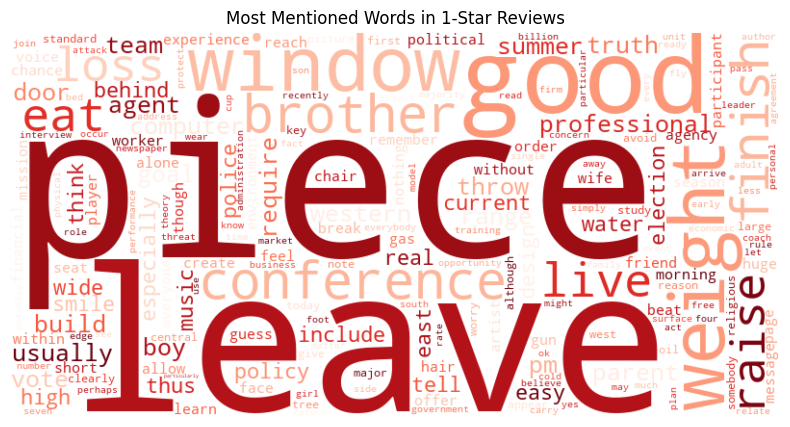

In [251]:
# 9. What are the most mentioned words in 1-star reviews?

one_star_reviews = df[df["rating"] == 1]["clean_review"]
one_star_text = " ".join(one_star_reviews)

one_star_wc = WordCloud(width=800,height=400,background_color="white",colormap="Reds").generate(one_star_text)

plt.figure(figsize=(10, 5))
plt.imshow(one_star_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Mentioned Words in 1-Star Reviews")
plt.show()


In [252]:
df['version'].value_counts()

version
5.9.6    3
1.4.7    3
4.7.3    3
3.0.6    3
2.1.7    3
        ..
2.3.8    1
1.9.3    1
2.3.4    1
3.9.6    1
3.1.3    1
Name: count, Length: 197, dtype: int64

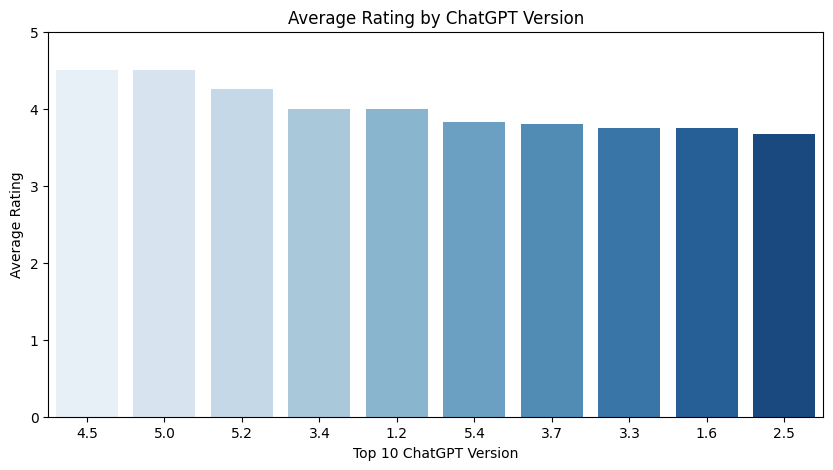

In [253]:
# 10. What ChatGPT version received the highest average rating?

df["major_version"] = df["version"].astype(str).str.extract(r"(\d+\.\d+)")

version_avg = (df.groupby("major_version")["rating"].mean().reset_index().sort_values(by="rating", ascending=False))
version_avg = version_avg.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(data=version_avg,x="major_version",y="rating",palette="Blues")

plt.title("Average Rating by ChatGPT Version")
plt.xlabel("Top 10 ChatGPT Version")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.show()